In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
from torch.optim import lr_scheduler
import torch.backends.cudnn as cudnn
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import time
import os
import numpy as np
from PIL import Image
from tempfile import TemporaryDirectory

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(device)
cudnn.benchmark = True
plt.ion()   # interactive mode

cuda


In [2]:
# Aggregating datasets
# Data augmentation and normalization for training
# Just normalization for validation
data_transforms = {
    'training': transforms.Compose([
        transforms.Resize(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

data_dir = 'image_data'
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x),
                                          data_transforms[x])
                  for x in ['training', 'test']}
dataloaders = {x: data.DataLoader(image_datasets[x], batch_size=4,
                                             shuffle=True, num_workers=4)
              for x in ['training', 'test']}
dataset_sizes = {x: len(image_datasets[x]) for x in ['training', 'test']}
class_names = image_datasets['training'].classes
print(class_names)

['autotuned', 'original']


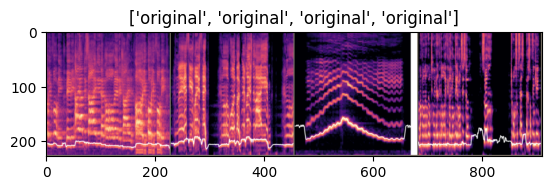

In [3]:
def imshow(inp, title=None):
    """Display image for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)  # pause a bit so that plots are updated


# Get a batch of training data
inputs, classes = next(iter(dataloaders['training']))

# Make a grid from batch
out = torchvision.utils.make_grid(inputs)

imshow(out, title=[class_names[x] for x in classes])

In [4]:
from IPython.display import clear_output

epochs = []
losses = {'training' : [], 'test' : []}
accs = {'training' : [], 'test' : []}
def train_model(model, criterion, optimizer, num_epochs=25):
    since = time.time()

    # Create a temporary directory to save training checkpoints
    with TemporaryDirectory() as tempdir:
        best_model_params_path = os.path.join(tempdir, 'best_model_params.pt')

        torch.save(model.state_dict(), best_model_params_path)
        best_acc = 0.0

        for epoch in range(num_epochs):
            print(f'Epoch {epoch}/{num_epochs - 1}')
            print('-' * 10)
            epochs.append(epoch)

            # Each epoch has a training and validation phase
            for phase in ['training', 'test']:
                if phase == 'training':
                    model.train()  # Set model to training mode
                else:
                    model.eval()   # Set model to evaluate mode

                running_loss = 0.0
                running_corrects = 0

                # Iterate over data.
                for inputs, labels in dataloaders[phase]:
                    inputs = inputs.to(device)
                    labels = labels.to(device)

                    # zero the parameter gradients
                    optimizer.zero_grad()

                    # forward
                    # track history if only in train
                    with torch.set_grad_enabled(phase == 'training'):
                        outputs = model(inputs)
                        _, preds = torch.max(outputs, 1)
                        loss = criterion(outputs, labels)

                        # backward + optimize only if in training phase
                        if phase == 'training':
                            loss.backward()
                            optimizer.step()

                    # statistics
                    running_loss += loss.item() * inputs.size(0)
                    running_corrects += torch.sum(preds == labels.data)
                #if phase == 'training':

                epoch_loss = running_loss / dataset_sizes[phase]
                epoch_acc = running_corrects.double() / dataset_sizes[phase]
                losses[phase].append(epoch_loss)
                accs[phase].append(epoch_acc.cpu())
                print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

                # deep copy the model
                if phase == 'test' and epoch_acc > best_acc:
                    best_acc = epoch_acc
                    torch.save(model.state_dict(), best_model_params_path)
                
            clear_output(wait=True)
            plt.figure(figsize=(10, 6))
            plt.plot(epochs, losses['training'], label='train loss')
            plt.plot(epochs, losses['test'], label='val loss', color='red')
            plt.title('loss plot')
            plt.xlabel('epoch')
            plt.ylabel('loss')
            plt.legend()
            plt.grid(True)
            plt.show()

            plt.figure(figsize=(10, 6))
            plt.plot(epochs, accs['training'], label='train acc')
            plt.plot(epochs, accs['test'], label='val acc', color='red')
            plt.title('acc plot')
            plt.xlabel('epoch')
            plt.ylabel('acc')
            plt.legend()
            plt.grid(True)
            plt.show()
                
            print()

        time_elapsed = time.time() - since
        print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
        print(f'Best val Acc: {best_acc:4f}')

        # load best model weights
        model.load_state_dict(torch.load(best_model_params_path, weights_only=True))
    return model

def visualize_model(model, num_images=6):
    was_training = model.training
    model.eval()
    images_so_far = 0
    fig = plt.figure()

    with torch.no_grad():
        for i, (inputs, labels) in enumerate(dataloaders['val']):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for j in range(inputs.size()[0]):
                images_so_far += 1
                ax = plt.subplot(num_images//2, 2, images_so_far)
                ax.axis('off')
                ax.set_title(f'predicted: {class_names[preds[j]]}')
                imshow(inputs.cpu().data[j])

                if images_so_far == num_images:
                    model.train(mode=was_training)
                    return
        model.train(mode=was_training)

In [5]:
model = models.resnet50(weights='DEFAULT') # 161 layers
for param in model.parameters():
    param.requires_grad = False

num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 2)
model = model.to(device)
model = torch.compile(model)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=0.001)
#lr_schedule = optim.lr_scheduler.ConstantLR(optimizer, factor=1.0, total_iters=5)

@torch.compile(fullgraph=False)
def compiled_step():
    optimizer.step()

@torch.compile(fullgraph=False)
def compiled_loss(outputs, labels):
    return criterion(outputs, labels)

#model_conv = train_model(model, criterion, optimizer, num_epochs=50)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to C:\Users\User/.cache\torch\hub\checkpoints\resnet50-11ad3fa6.pth
100%|██████████| 97.8M/97.8M [00:04<00:00, 22.3MB/s]


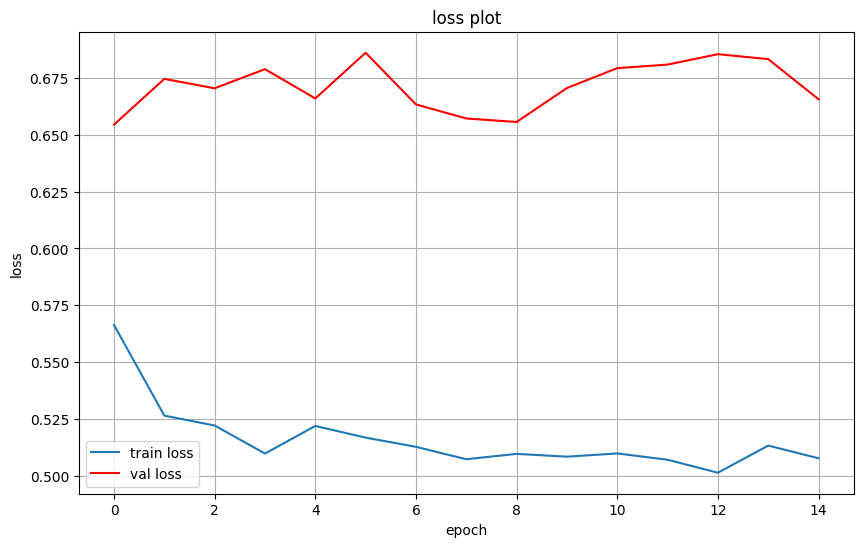

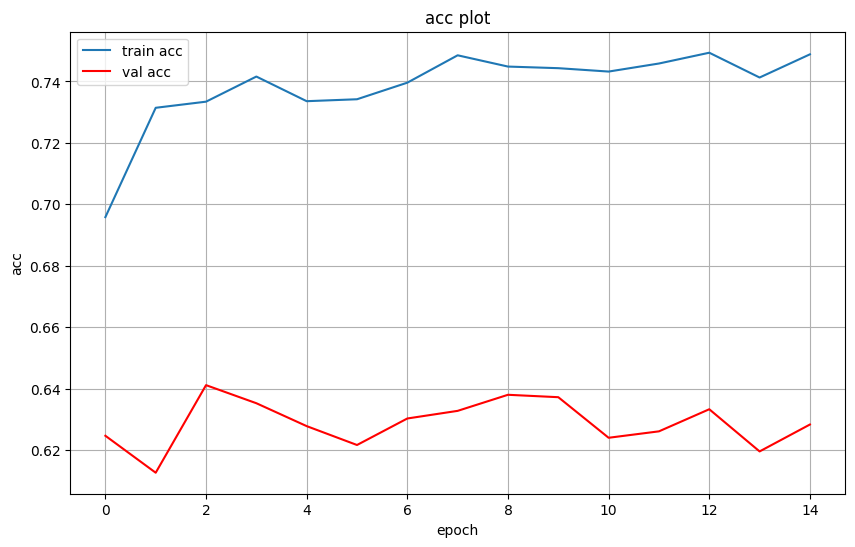


Epoch 15/49
----------


KeyboardInterrupt: 

In [6]:
model_conv = train_model(model, criterion, optimizer, num_epochs=50)